# Analyse des professions

Ce notebook compte les professions présentes dans `transcripts_job_types_full.csv` et calcule leur fréquence.

## 1. Importer pandas

Importer la bibliothèque pandas pour analyser les données.

In [1]:
import pandas as pd

## 2. Charger le tableau des professions

Lire le fichier source dans un DataFrame et sélectionner la colonne `job_type`, qui contient les professions.

In [2]:
csv_path = "transcripts_job_types_full.csv"
df = pd.read_csv(csv_path)

print(f"Nombre de lignes : {len(df):,}".replace(",", " "))
print(f"Colonne analysée : job_type")
df[["job_type"]].head()

Nombre de lignes : 1 250
Colonne analysée : job_type


,job_type
0,Analyste
1,Chercheur
2,Ingénieur matériaux
3,Développeur
4,Chercheur


## 3. Nettoyer la colonne profession

Supprimer les valeurs manquantes, retirer les espaces superflus et harmoniser la casse afin de regrouper les variantes d’une même profession.

In [3]:
professions = (
    df["job_type"]
    .dropna()
    .astype(str)
    .str.strip()
    .replace("", pd.NA)
    .dropna()
    .str.lower()
    .str.capitalize()
)

print(f"Professions valides : {len(professions):,}".replace(",", " "))

Professions valides : 1 250


## 4. Compter les professions

Calculer l’effectif de chaque profession avec `value_counts()`.

In [4]:
effectifs = professions.value_counts()
effectifs.head(10)

job_type
Enseignant     110
Développeur     86
Assistant       63
Écrivain        38
Chercheur       25
Analyste        21
Recherche       21
Rédacteur       21
Artisan         21
Créatif         20
Name: count, dtype: int64

## 5. Calculer les fréquences

Diviser chaque effectif par le nombre total de professions valides, puis convertir la fréquence en pourcentage.

In [5]:
frequences = effectifs / effectifs.sum()
pourcentages = frequences * 100

## 6. Afficher le tableau récapitulatif

Présenter les professions par effectif décroissant avec leur fréquence et leur pourcentage.

In [6]:
tableau_professions = pd.DataFrame(
    {
        "Profession": effectifs.index,
        "Effectif": effectifs.values,
        "Fréquence": frequences.values,
        "Pourcentage": pourcentages.values,
    }
).sort_values("Effectif", ascending=False, ignore_index=True)

tableau_professions.style.format(
    {"Fréquence": "{:.4f}", "Pourcentage": "{:.2f} %"}
)

,Profession,Effectif,Fréquence,Pourcentage
0,Enseignant,110,0.0880,8.80 %
1,Développeur,86,0.0688,6.88 %
2,Assistant,63,0.0504,5.04 %
3,Écrivain,38,0.0304,3.04 %
4,Chercheur,25,0.0200,2.00 %
5,Analyste,21,0.0168,1.68 %
6,Recherche,21,0.0168,1.68 %
7,Rédacteur,21,0.0168,1.68 %
8,Artisan,21,0.0168,1.68 %
9,Créatif,20,0.0160,1.60 %


In [7]:
print(f"Nombre de lignes du fichier : {len(df):,}".replace(",", " "))
print(f"Nombre de professions valides : {effectifs.sum():,}".replace(",", " "))
print(f"Nombre de professions distinctes : {len(effectifs):,}".replace(",", " "))
print(f"Somme des fréquences : {frequences.sum():.4f}")
print(f"Somme des pourcentages : {pourcentages.sum():.2f} %")

Nombre de lignes du fichier : 1 250
Nombre de professions valides : 1 250
Nombre de professions distinctes : 439
Somme des fréquences : 1.0000
Somme des pourcentages : 100.00 %


## 7. Regrouper les professions en 20 modalités

Les intitulés détaillés sont regroupés dans 19 grandes familles professionnelles. Les intitulés qui ne correspondent à aucune règle sont classés dans `Autres`.

In [11]:
import re
import unicodedata

modalites = [
    "Informatique et logiciel",
    "Données et analyse",
    "Recherche et sciences",
    "Enseignement et formation",
    "Rédaction et édition",
    "Arts, design et création",
    "Communication, marketing et médias",
    "Administration et assistance",
    "Management et gestion de projet",
    "Finance, comptabilité et audit",
    "Droit et justice",
    "Santé et soins",
    "Ingénierie et métiers techniques",
    "Commerce, vente et relation client",
    "Conseil",
    "Artisanat et métiers manuels",
    "Hôtellerie, restauration et alimentation",
    "Ressources humaines",
    "Logistique et transport",
    "Autres",
]

regles = [
    ("Informatique et logiciel", r"developp|logiciel|informat|programme|programming|devops|cyber|pentest|qa tester|web|jeu|prompt engineer|automatisation"),
    ("Données et analyse", r"analyst|analys|data|statistic|biostat|donnee"),
    ("Recherche et sciences", r"recherch|chercheur|scientif|science|biolog|astrophys|astronom|physici|chimi|biotech|toxicolog|geolog|mathem|math\b|laboratoire|academ|universit|doctorant"),
    ("Enseignement et formation", r"enseign|educat|format|tuteur|tutor|pedagog|professeur"),
    ("Santé et soins", r"medec|medical|sante|soin|soignant|infirm|nurse|therap|pharmac|psycholog|dentiste|veterin"),
    ("Droit et justice", r"avocat|jurist|jurid|droit|paralegal|notaire|justice"),
    ("Finance, comptabilité et audit", r"comptab|accountant|financ|banqu|audit|fiscal|controleur de gestion"),
    ("Ressources humaines", r"ressources humaines|recrut|rh\b|talent|paie"),
    ("Logistique et transport", r"logisti|transport|chauffeur|livreur|supply|magasinier"),
    ("Commerce, vente et relation client", r"vend|vente|sales|reseller|commerce|retail|client|commercial|e-commerce|immobilier|boutique"),
    ("Hôtellerie, restauration et alimentation", r"cuisin|boulanger|patiss|restaur|hoteller|serveur|chef\b|aliment"),
    ("Rédaction et édition", r"ecriv|redact|auteur|writer|copywriter|edit|librair|librarian|biblioth|transcri|traduct"),
    ("Arts, design et création", r"artist|creatif|createur|creation|design|photograph|illustr|composit|musicien|music\b|graph|video"),
    ("Communication, marketing et médias", r"marketing|communication|journal|media|contenu|seo|publicit|producteur|influenc"),
    ("Artisanat et métiers manuels", r"artisan|manuel|jardin|menuis|plomb|macon|coutur|coiffeur|nail"),
    ("Ingénierie et métiers techniques", r"ingenieur|ingenier|engineer|technicien|technique|technical|architecte|mecan|electri|maintenance"),
    ("Management et gestion de projet", r"manager|management|gestionnaire|project manager|product owner|superviseur|coordinateur|direction|directeur|entrepren"),
    ("Administration et assistance", r"assistant|administrat|secretair|bureau|agent\b|support|service"),
    ("Conseil", r"consult|conseil|conseiller|coach|expert"),
]


def normaliser_texte(texte):
    texte = unicodedata.normalize("NFKD", str(texte))
    return "".join(caractere for caractere in texte if not unicodedata.combining(caractere)).lower()


def attribuer_modalite(profession):
    profession_normalisee = normaliser_texte(profession)
    for modalite, motif in regles:
        if re.search(motif, profession_normalisee):
            return modalite
    return "Autres"


groupes_professions = pd.DataFrame({"Profession": professions})
groupes_professions["Modalité"] = groupes_professions["Profession"].apply(attribuer_modalite)
groupes_professions["Modalité"] = pd.Categorical(
    groupes_professions["Modalité"], categories=modalites
)

In [12]:
effectifs_modalites = (
    groupes_professions["Modalité"]
    .value_counts(sort=False)
    .reindex(modalites, fill_value=0)
)

tableau_modalites = pd.DataFrame(
    {
        "Modalité": effectifs_modalites.index,
        "Effectif": effectifs_modalites.values,
    }
)
tableau_modalites["Fréquence"] = tableau_modalites["Effectif"] / tableau_modalites["Effectif"].sum()
tableau_modalites["Pourcentage"] = tableau_modalites["Fréquence"] * 100
tableau_modalites = tableau_modalites.sort_values("Effectif", ascending=False, ignore_index=True)

assert len(tableau_modalites) == 20
assert tableau_modalites["Effectif"].sum() == len(professions)
assert abs(tableau_modalites["Fréquence"].sum() - 1) < 1e-12

print(f"Nombre de modalités : {len(tableau_modalites)}")
print(f"Effectif total : {tableau_modalites['Effectif'].sum():,}".replace(",", " "))
print(f"Somme des pourcentages : {tableau_modalites['Pourcentage'].sum():.2f} %")

tableau_modalites.style.format(
    {"Fréquence": "{:.4f}", "Pourcentage": "{:.2f} %"}
)

Nombre de modalités : 20
Effectif total : 1 250
Somme des pourcentages : 100.00 %


,Modalité,Effectif,Fréquence,Pourcentage
0,Informatique et logiciel,164,0.1312,13.12 %
1,Enseignement et formation,145,0.1160,11.60 %
2,Rédaction et édition,120,0.0960,9.60 %
3,Autres,113,0.0904,9.04 %
4,Administration et assistance,111,0.0888,8.88 %
5,"Arts, design et création",106,0.0848,8.48 %
6,Recherche et sciences,103,0.0824,8.24 %
7,Ingénierie et métiers techniques,69,0.0552,5.52 %
8,Données et analyse,54,0.0432,4.32 %
9,Management et gestion de projet,43,0.0344,3.44 %


### Contrôle de la catégorie « Autres »

Ce tableau permet d’identifier les intitulés non couverts par les règles et d’affiner ultérieurement la taxonomie.

In [13]:
intitules_autres = (
    groupes_professions.loc[groupes_professions["Modalité"] == "Autres", "Profession"]
    .value_counts()
    .rename_axis("Profession")
    .reset_index(name="Effectif")
)

intitules_autres.head(30)

,Profession,Effectif
0,Freelance,4
1,Étudiant,2
2,Métier intellectuel,2
3,Outils,2
4,Modérateur,1
5,Non-profit,1
6,Hr,1
7,Kennel,1
8,Curateur,1
9,Productivité,1


# Analyse des aspects de l’expérience

Cette section compte les aspects présents dans `transcripts_experience_aspects_top7_full.csv`, calcule leur fréquence et les regroupe en 20 modalités thématiques.

In [14]:
aspect_csv_path = "transcripts_experience_aspects_top7_full.csv"
colonnes_aspects = [f"aspect_{numero}" for numero in range(1, 8)]

df_aspects = pd.read_csv(aspect_csv_path)
aspects = (
    df_aspects[colonnes_aspects]
    .stack()
    .dropna()
    .astype(str)
    .str.strip()
)
aspects = aspects[aspects.ne("")]

effectifs_aspects = aspects.value_counts()
tableau_aspects = effectifs_aspects.rename_axis("Aspect").reset_index(name="Effectif")
tableau_aspects["Fréquence"] = tableau_aspects["Effectif"] / len(aspects)
tableau_aspects["Pourcentage"] = tableau_aspects["Fréquence"] * 100

print(f"Nombre d'entretiens : {len(df_aspects):,}".replace(",", " "))
print(f"Entretiens avec au moins un aspect : {df_aspects[colonnes_aspects].notna().any(axis=1).sum():,}".replace(",", " "))
print(f"Nombre total d'aspects : {len(aspects):,}".replace(",", " "))
print(f"Nombre de libellés distincts : {aspects.nunique():,}".replace(",", " "))

display(tableau_aspects.head(30).style.format({"Fréquence": "{:.4f}", "Pourcentage": "{:.2f} %"}))

Nombre d'entretiens : 1 250
Entretiens avec au moins un aspect : 513
Nombre total d'aspects : 3 566
Nombre de libellés distincts : 2 608


,Aspect,Effectif,Fréquence,Pourcentage
0,Usages de l'IA,130,0.0365,3.65 %
1,Collaboration avec l'IA,72,0.0202,2.02 %
2,Limites de l'IA,69,0.0193,1.93 %
3,Effets sur la pratique,61,0.0171,1.71 %
4,Bénéfices de l'IA,56,0.0157,1.57 %
5,Usages,52,0.0146,1.46 %
6,Bénéfices,41,0.0115,1.15 %
7,Limites,37,0.0104,1.04 %
8,Préoccupations,23,0.0064,0.64 %
9,Usages de l'IA dans le,20,0.0056,0.56 %


## Regroupement en 20 modalités

Les règles sont appliquées dans l’ordre : les thèmes précis sont recherchés avant les catégories générales. La normalisation ignore les majuscules et les accents.

In [15]:
modalites_aspects = [
    "Gain de temps et productivité",
    "Recherche et information",
    "Rédaction et communication",
    "Code et automatisation",
    "Analyse de données",
    "Créativité et idéation",
    "Apprentissage et formation",
    "Organisation et planification",
    "Collaboration humain-IA",
    "Vérification et contrôle humain",
    "Fiabilité, erreurs et qualité",
    "Contraintes techniques",
    "Prompts, contexte et personnalisation",
    "Éthique, confidentialité et sécurité",
    "Effets professionnels, autonomie et adoption",
    "Préoccupations générales",
    "Bénéfices généraux",
    "Limites générales",
    "Usages généraux",
    "Autres",
]

regles_aspects = [
    ("Gain de temps et productivité", r"gain.*temps|temps.*(gain|econom)|productiv|efficac|rapidit|acceler|reduction.*temps|econom.*temps"),
    ("Recherche et information", r"recherch|information|document|source|veille|bibliograph|synthes|resume|explor"),
    ("Rédaction et communication", r"redact|ecrit|texte|contenu|email|courriel|communication|reformul|correction|traduct|langue"),
    ("Code et automatisation", r"\bcode\b|codage|programm|developp|script|debug|automatis|tache.*repet|processus"),
    ("Analyse de données", r"donnee|\bdata\b|analys|statist|visualis|tableau|calcul|modelis|interpret"),
    ("Créativité et idéation", r"creativ|creation|idee|ideation|brainstorm|inspir|imagin|innovation"),
    ("Apprentissage et formation", r"apprent|formation|comprehension|pedagog|enseign|connaiss"),
    ("Organisation et planification", r"organi|planif|agenda|gestion|administr|structur|prioris"),
    ("Collaboration humain-IA", r"collabor|interaction.*ia|dialog|partenaire|assistant|co.?creation|humain.*ia|ia.*humain|equipe|collegue|binome"),
    ("Vérification et contrôle humain", r"verif|controle|validat|relecture|supervision|revue|jugement humain|intervention humaine|manuel"),
    ("Fiabilité, erreurs et qualité", r"fiabil|erreur|hallucin|precision|exact|qualite|incoher|fauss|incorrect|inexact|resultat"),
    ("Contraintes techniques", r"techni|performance|lenteur|\blent\b|\bbug\b|panne|connexion|acces|\bcout\b|payant|token|memoire|modele"),
    ("Prompts, contexte et personnalisation", r"prompt|personnalis|adapt|context|iterat|affin|formul|instruction|parametr"),
    ("Éthique, confidentialité et sécurité", r"ethiq|confidential|securit|prive|vie privee|personnelle|\bbiais\b|transparen|propriete|\bdroit\b|copyright|responsab|environnement"),
    ("Effets professionnels, autonomie et adoption", r"pratique|profession|metier|travail|emploi|autonom|depend|preference|satisfaction|confiance|adoption|integration|futur|avenir|remplac|competence|frustr|resist|accept|motivation|anxiet|\bpeur\b|inquiet|impact|\beffet|changement|evolution|deshuman"),
    ("Préoccupations générales", r"preoccup|risque|crainte|danger|probleme|difficulte|incertitude"),
    ("Bénéfices généraux", r"benefic|avantage|\butile|\baide\b|facilit|amelior"),
    ("Limites générales", r"limite|restriction|insuffis|manque|incapac|faiblesse|defaut"),
    ("Usages généraux", r"usage|utilis|\boutil|recours|application|emploie|quotidien"),
]


def attribuer_modalite_aspect(intitule):
    intitule_normalise = normaliser_texte(intitule)
    for modalite, motif in regles_aspects:
        if re.search(motif, intitule_normalise):
            return modalite
    return "Autres"


groupes_aspects = pd.DataFrame({
    "Aspect": aspects.values,
    "Modalité": aspects.map(attribuer_modalite_aspect).values,
})
groupes_aspects["Modalité"] = pd.Categorical(
    groupes_aspects["Modalité"], categories=modalites_aspects, ordered=True
)

effectifs_modalites_aspects = groupes_aspects["Modalité"].value_counts(sort=False)
tableau_modalites_aspects = effectifs_modalites_aspects.rename_axis("Modalité").reset_index(name="Effectif")
tableau_modalites_aspects["Fréquence"] = tableau_modalites_aspects["Effectif"] / len(groupes_aspects)
tableau_modalites_aspects["Pourcentage"] = tableau_modalites_aspects["Fréquence"] * 100
tableau_modalites_aspects = tableau_modalites_aspects.sort_values("Effectif", ascending=False, ignore_index=True)

assert len(tableau_modalites_aspects) == 20
assert tableau_modalites_aspects["Effectif"].sum() == len(aspects)
assert abs(tableau_modalites_aspects["Fréquence"].sum() - 1) < 1e-12

print(f"Total regroupé : {tableau_modalites_aspects['Effectif'].sum():,}".replace(",", " "))
print(f"Somme des pourcentages : {tableau_modalites_aspects['Pourcentage'].sum():.2f} %")
display(tableau_modalites_aspects.style.format({"Fréquence": "{:.4f}", "Pourcentage": "{:.2f} %"}))

Total regroupé : 3 566
Somme des pourcentages : 100.00 %


,Modalité,Effectif,Fréquence,Pourcentage
0,"Effets professionnels, autonomie et adoption",450,0.1262,12.62 %
1,Usages généraux,393,0.1102,11.02 %
2,Autres,387,0.1085,10.85 %
3,Limites générales,244,0.0684,6.84 %
4,Bénéfices généraux,224,0.0628,6.28 %
5,Collaboration humain-IA,220,0.0617,6.17 %
6,Gain de temps et productivité,203,0.0569,5.69 %
7,Recherche et information,187,0.0524,5.24 %
8,Créativité et idéation,180,0.0505,5.05 %
9,Rédaction et communication,155,0.0435,4.35 %


## Contrôle de la catégorie « Autres »

Ce tableau affiche les libellés non reconnus les plus fréquents. Il permet d’identifier rapidement les règles qui pourraient être enrichies.

In [16]:
intitules_autres_aspects = (
    groupes_aspects.loc[groupes_aspects["Modalité"] == "Autres", "Aspect"]
    .value_counts()
    .rename_axis("Aspect non classé")
    .reset_index(name="Effectif")
)

print(f"Part classée dans « Autres » : {(groupes_aspects['Modalité'] == 'Autres').mean():.2%}")
display(intitules_autres_aspects.head(30))

Part classée dans « Autres » : 10.85%


,Aspect non classé,Effectif
0,Aspects principaux de l'expérience vécue,2
1,```,2
2,Stigmatisation de l'IA,2
3,Préfère rédiger soi-même,2
4,I mostly use AI for,2
5,That sounds good,2
6,AI guide la construction d'un,1
7,AI filtre les joueurs selon,1
8,Aspects principaux de l’expérience vécue,1
9,Méthodes traditionnelles préférées,1


# AFCM des nouvelles modalités

Cette analyse reprend le calcul du notebook de référence, mais utilise exclusivement les modalités regroupées des professions et des aspects. Pour chaque entretien, une même modalité d’aspect n’est comptée qu’une fois.

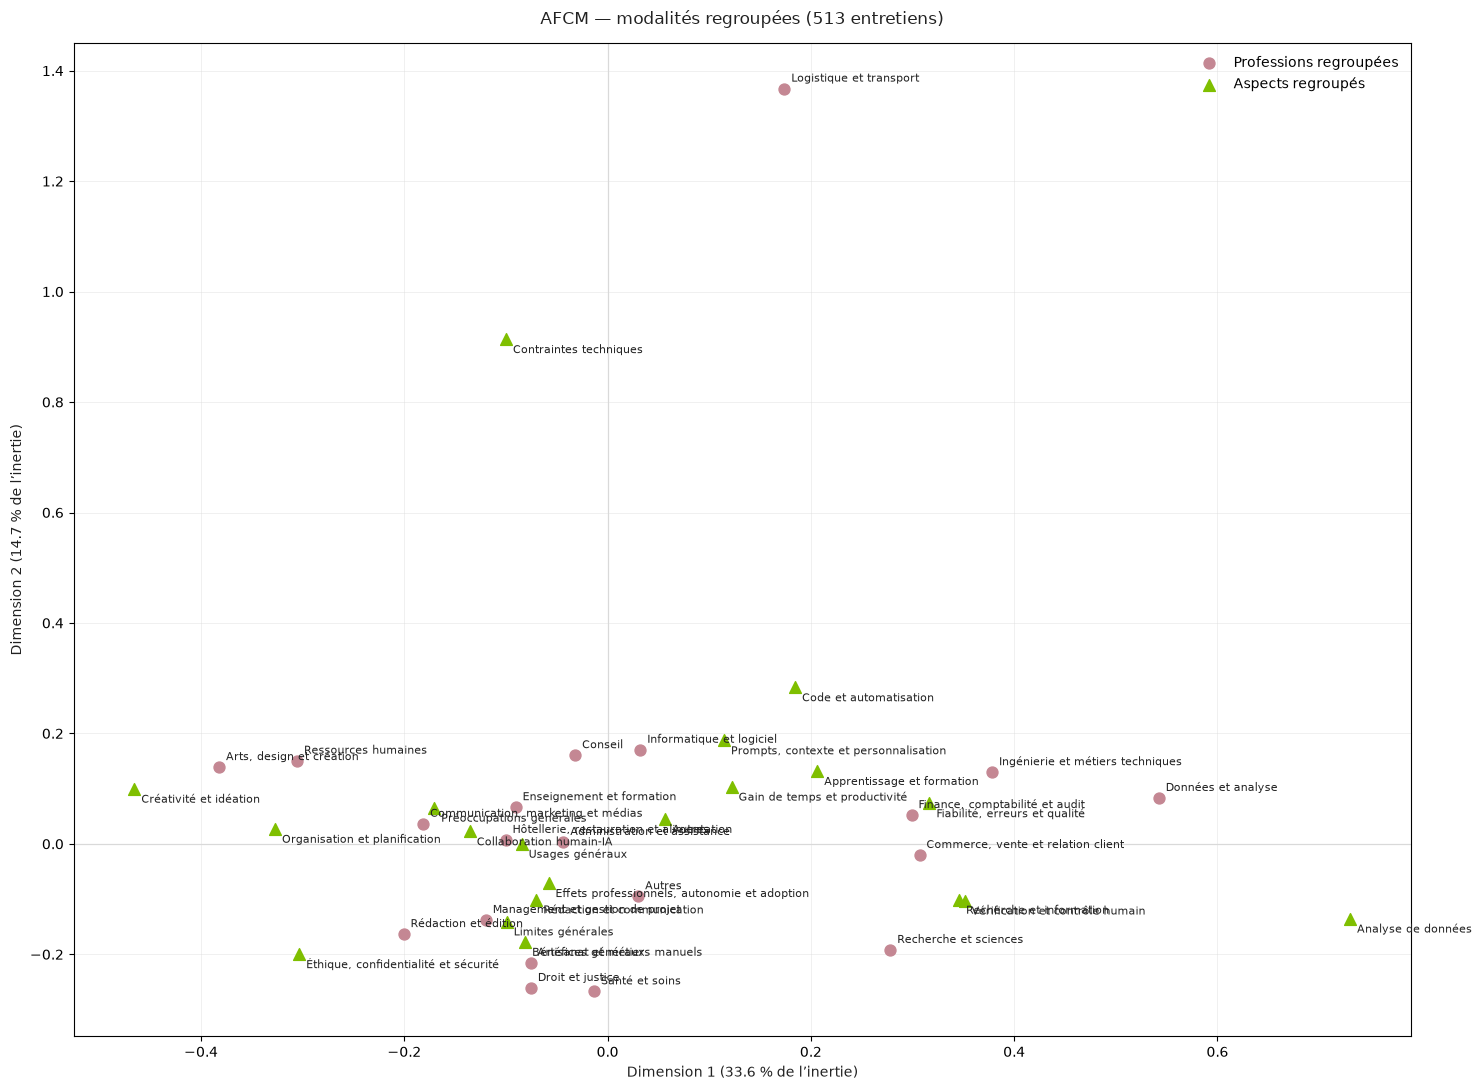

Entretiens analysés : 513
Paires profession-aspect regroupées : 2967
Modalités actives : 20 professions × 20 aspects
Inertie expliquée par les deux axes : 48.3 %
Tableau de contingence : /home/cbenavent/test/Mistral4/data/results/afcm_modalites_regroupees_contingence.csv
Coordonnées : /home/cbenavent/test/Mistral4/data/results/afcm_modalites_regroupees_coordonnees.csv
Inertie : /home/cbenavent/test/Mistral4/data/results/afcm_modalites_regroupees_inertie.csv
Carte factorielle : /home/cbenavent/test/Mistral4/images/afcm_modalites_regroupees.png


In [19]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

# Build one grouped profession and a set of grouped aspects per transcript.
professions_par_id = (
    df[["transcript_id", "job_type"]]
    .dropna(subset=["transcript_id", "job_type"])
    .assign(
        transcript_id=lambda tableau: tableau["transcript_id"].astype(str).str.strip(),
        profession_modalite=lambda tableau: tableau["job_type"].map(attribuer_modalite),
    )
    .set_index("transcript_id")["profession_modalite"]
)

lignes_afcm = []
for _, ligne in df_aspects.iterrows():
    transcript_id = str(ligne["transcript_id"]).strip()
    if transcript_id not in professions_par_id.index:
        continue
    aspects_bruts = {
        str(ligne[colonne]).strip()
        for colonne in colonnes_aspects
        if pd.notna(ligne[colonne]) and str(ligne[colonne]).strip()
    }
    aspects_modalites = {
        attribuer_modalite_aspect(aspect)
        for aspect in aspects_bruts
    }
    for aspect_modalite in aspects_modalites:
        lignes_afcm.append({
            "transcript_id": transcript_id,
            "Profession": professions_par_id.loc[transcript_id],
            "Aspect": aspect_modalite,
        })

paires_afcm = pd.DataFrame(lignes_afcm)
if paires_afcm.empty:
    raise ValueError("Aucune paire de modalités regroupées n’est exploitable.")

modalites_professions_afcm = [
    modalite for modalite in modalites
    if modalite in set(paires_afcm["Profession"])
]
modalites_aspects_afcm = [
    modalite for modalite in modalites_aspects
    if modalite in set(paires_afcm["Aspect"])
]

tableau_contingence_afcm = pd.crosstab(
    pd.Categorical(
        paires_afcm["Profession"],
        categories=modalites_professions_afcm,
        ordered=True,
    ),
    pd.Categorical(
        paires_afcm["Aspect"],
        categories=modalites_aspects_afcm,
        ordered=True,
    ),
    dropna=False,
)
tableau_contingence_afcm.index.name = "Profession"
tableau_contingence_afcm.columns.name = "Aspect"

contingence_afcm = tableau_contingence_afcm.to_numpy(dtype=float)
assert set(tableau_contingence_afcm.index).issubset(set(modalites))
assert set(tableau_contingence_afcm.columns).issubset(set(modalites_aspects))
assert int(contingence_afcm.sum()) == len(paires_afcm)
assert (contingence_afcm.sum(axis=0) > 0).all()
assert (contingence_afcm.sum(axis=1) > 0).all()

# Correspondence analysis: SVD of the standardized residual matrix.
total_afcm = contingence_afcm.sum()
probabilites_afcm = contingence_afcm / total_afcm
masses_lignes_afcm = probabilites_afcm.sum(axis=1)
masses_colonnes_afcm = probabilites_afcm.sum(axis=0)
effectifs_attendus_afcm = np.outer(masses_lignes_afcm, masses_colonnes_afcm)
residus_standardises_afcm = (
    probabilites_afcm - effectifs_attendus_afcm
) / np.sqrt(effectifs_attendus_afcm)

vecteurs_lignes_afcm, valeurs_singulieres_afcm, vecteurs_colonnes_afcm = np.linalg.svd(
    residus_standardises_afcm,
    full_matrices=False,
)
valeurs_propres_afcm = valeurs_singulieres_afcm**2
inertie_totale_afcm = valeurs_propres_afcm.sum()
if np.count_nonzero(valeurs_propres_afcm > 1e-12) < 2 or inertie_totale_afcm <= 0:
    raise ValueError("Les données ne permettent pas de construire une carte en deux dimensions.")

coordonnees_professions_afcm = (
    vecteurs_lignes_afcm[:, :2] / np.sqrt(masses_lignes_afcm[:, None])
) * valeurs_singulieres_afcm[:2]
coordonnees_aspects_afcm = (
    vecteurs_colonnes_afcm[:2, :].T / np.sqrt(masses_colonnes_afcm[:, None])
) * valeurs_singulieres_afcm[:2]
inertie_expliquee_afcm = valeurs_propres_afcm[:2] / inertie_totale_afcm * 100

coordonnees_afcm = pd.concat(
    [
        pd.DataFrame({
            "Catégorie": "Profession",
            "Modalité": modalites_professions_afcm,
            "Dimension 1": coordonnees_professions_afcm[:, 0],
            "Dimension 2": coordonnees_professions_afcm[:, 1],
            "Masse": masses_lignes_afcm,
        }),
        pd.DataFrame({
            "Catégorie": "Aspect",
            "Modalité": modalites_aspects_afcm,
            "Dimension 1": coordonnees_aspects_afcm[:, 0],
            "Dimension 2": coordonnees_aspects_afcm[:, 1],
            "Masse": masses_colonnes_afcm,
        }),
    ],
    ignore_index=True,
)
inertie_afcm = pd.DataFrame({
    "Dimension": np.arange(1, len(valeurs_propres_afcm) + 1),
    "Inertie": valeurs_propres_afcm,
    "Pourcentage d’inertie": valeurs_propres_afcm / inertie_totale_afcm * 100,
})

resultats_afcm_dir = Path("data/results")
images_afcm_dir = Path("images")
resultats_afcm_dir.mkdir(parents=True, exist_ok=True)
images_afcm_dir.mkdir(parents=True, exist_ok=True)

chemin_contingence_afcm = resultats_afcm_dir / "afcm_modalites_regroupees_contingence.csv"
chemin_coordonnees_afcm = resultats_afcm_dir / "afcm_modalites_regroupees_coordonnees.csv"
chemin_inertie_afcm = resultats_afcm_dir / "afcm_modalites_regroupees_inertie.csv"
chemin_figure_afcm = images_afcm_dir / "afcm_modalites_regroupees.png"

tableau_contingence_afcm.to_csv(chemin_contingence_afcm)
coordonnees_afcm.to_csv(chemin_coordonnees_afcm, index=False)
inertie_afcm.to_csv(chemin_inertie_afcm, index=False)

fig, ax = plt.subplots(figsize=(15, 11), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")
ax.axhline(0, color="#D9D9D9", linewidth=0.9, zorder=0)
ax.axvline(0, color="#D9D9D9", linewidth=0.9, zorder=0)
ax.grid(color="#D9D9D9", linewidth=0.5, alpha=0.55)

couleur_professions = "#C48793"
couleur_aspects = "#7FBF00"
ax.scatter(
    coordonnees_professions_afcm[:, 0],
    coordonnees_professions_afcm[:, 1],
    color=couleur_professions,
    marker="o",
    s=62,
    label="Professions regroupées",
    zorder=3,
)
ax.scatter(
    coordonnees_aspects_afcm[:, 0],
    coordonnees_aspects_afcm[:, 1],
    color=couleur_aspects,
    marker="^",
    s=72,
    label="Aspects regroupés",
    zorder=3,
)
for indice, modalite in enumerate(modalites_professions_afcm):
    ax.annotate(
        modalite,
        coordonnees_professions_afcm[indice],
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        color="#222222",
    )
for indice, modalite in enumerate(modalites_aspects_afcm):
    ax.annotate(
        modalite,
        coordonnees_aspects_afcm[indice],
        xytext=(5, -10),
        textcoords="offset points",
        fontsize=8,
        color="#222222",
    )

nombre_entretiens_afcm = paires_afcm["transcript_id"].nunique()
ax.set_title(
    f"AFCM — modalités regroupées ({nombre_entretiens_afcm} entretiens)",
    color="#222222",
    pad=14,
)
ax.set_xlabel(
    f"Dimension 1 ({inertie_expliquee_afcm[0]:.1f} % de l’inertie)",
    color="#222222",
)
ax.set_ylabel(
    f"Dimension 2 ({inertie_expliquee_afcm[1]:.1f} % de l’inertie)",
    color="#222222",
)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(chemin_figure_afcm, dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print(f"Entretiens analysés : {nombre_entretiens_afcm}")
print(f"Paires profession-aspect regroupées : {len(paires_afcm)}")
print(
    "Modalités actives : "
    f"{len(modalites_professions_afcm)} professions × "
    f"{len(modalites_aspects_afcm)} aspects"
)
print(f"Inertie expliquée par les deux axes : {inertie_expliquee_afcm.sum():.1f} %")
print(f"Tableau de contingence : {chemin_contingence_afcm.resolve()}")
print(f"Coordonnées : {chemin_coordonnees_afcm.resolve()}")
print(f"Inertie : {chemin_inertie_afcm.resolve()}")
print(f"Carte factorielle : {chemin_figure_afcm.resolve()}")

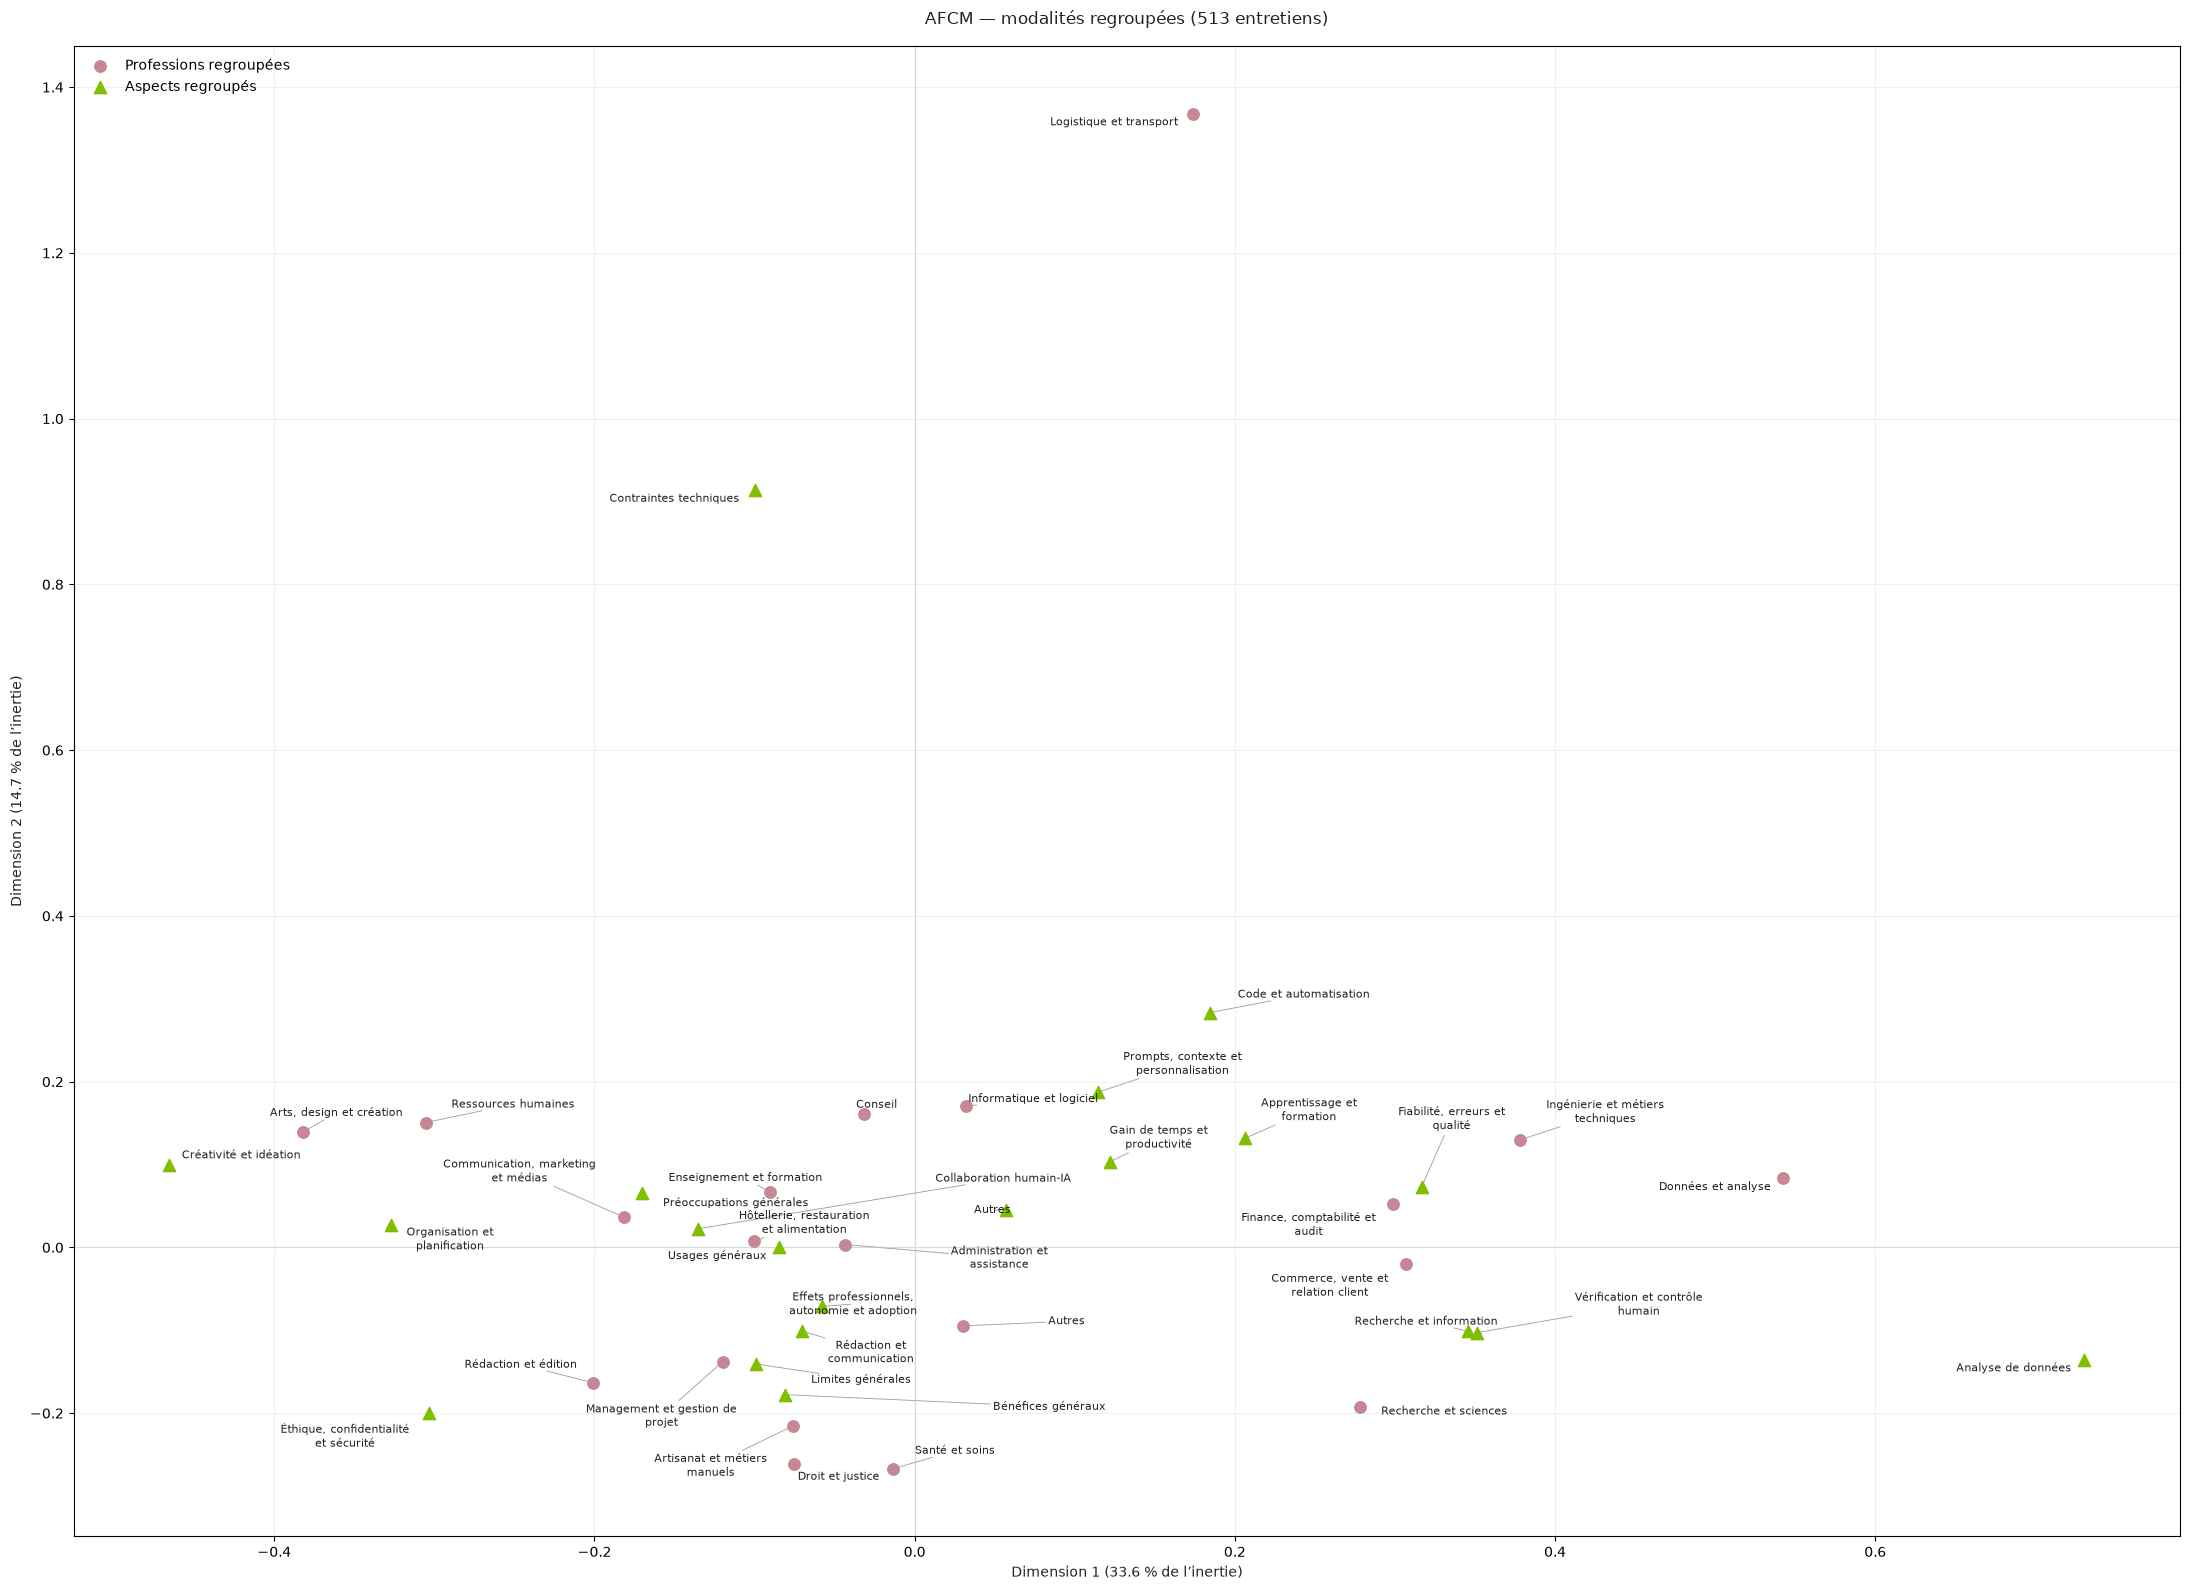

Carte factorielle avec rappel : /home/cbenavent/test/Mistral4/images/afcm_modalites_regroupees.png


In [23]:
from textwrap import fill

from adjustText import adjust_text

# Display every full label on the map and connect displaced labels to their points.
fig_finale, ax_final = plt.subplots(figsize=(22, 16), facecolor="#FFFFFF")
ax_final.set_facecolor("#FFFFFF")
ax_final.axhline(0, color="#D9D9D9", linewidth=0.9, zorder=0)
ax_final.axvline(0, color="#D9D9D9", linewidth=0.9, zorder=0)
ax_final.grid(color="#D9D9D9", linewidth=0.5, alpha=0.55)

ax_final.scatter(
    coordonnees_professions_afcm[:, 0],
    coordonnees_professions_afcm[:, 1],
    color=couleur_professions,
    marker="o",
    s=68,
    label="Professions regroupées",
    zorder=4,
)
ax_final.scatter(
    coordonnees_aspects_afcm[:, 0],
    coordonnees_aspects_afcm[:, 1],
    color=couleur_aspects,
    marker="^",
    s=78,
    label="Aspects regroupés",
    zorder=4,
)

coordonnees_toutes = np.vstack([
    coordonnees_professions_afcm,
    coordonnees_aspects_afcm,
])
libelles_tous = modalites_professions_afcm + modalites_aspects_afcm

textes_modalites = []
for (abscisse, ordonnee), libelle in zip(coordonnees_toutes, libelles_tous):
    textes_modalites.append(
        ax_final.text(
            abscisse,
            ordonnee,
            fill(libelle, width=25),
            fontsize=8,
            color="#222222",
            ha="center",
            va="center",
            zorder=5,
        )
    )

adjust_text(
    textes_modalites,
    x=coordonnees_toutes[:, 0],
    y=coordonnees_toutes[:, 1],
    target_x=coordonnees_toutes[:, 0],
    target_y=coordonnees_toutes[:, 1],
    ax=ax_final,
    expand=(1.08, 1.28),
    force_text=(0.35, 0.55),
    force_static=(0.18, 0.30),
    force_pull=(0.012, 0.018),
    max_move=(28, 28),
    explode_radius="auto",
    ensure_inside_axes=True,
    expand_axes=True,
    prevent_crossings=True,
    min_arrow_len=7,
    arrowprops={
        "arrowstyle": "-",
        "color": "#8A8A8A",
        "linewidth": 0.65,
        "alpha": 0.8,
    },
)

ax_final.set_title(
    f"AFCM — modalités regroupées ({nombre_entretiens_afcm} entretiens)",
    color="#222222",
    pad=16,
)
ax_final.set_xlabel(
    f"Dimension 1 ({inertie_expliquee_afcm[0]:.1f} % de l’inertie)",
    color="#222222",
)
ax_final.set_ylabel(
    f"Dimension 2 ({inertie_expliquee_afcm[1]:.1f} % de l’inertie)",
    color="#222222",
)
ax_final.legend(frameon=False, loc="upper left")
fig_finale.tight_layout()
fig_finale.savefig(
    chemin_figure_afcm,
    dpi=180,
    bbox_inches="tight",
    facecolor=fig_finale.get_facecolor(),
)
plt.show()
print(f"Carte factorielle avec rappel : {chemin_figure_afcm.resolve()}")